In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
(X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()
print("Dataset Information")
print("-" * 40)
print("Training images:", X_train_raw.shape)
print("Testing images:", X_test_raw.shape)
print("Image size:", X_train_raw.shape[1], "x", X_train_raw.shape[2])
print("Number of classes:", len(np.unique(y_train)))
print("Classes:", np.unique(y_train))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Dataset Information
----------------------------------------
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)
Image size: 28 x 28
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


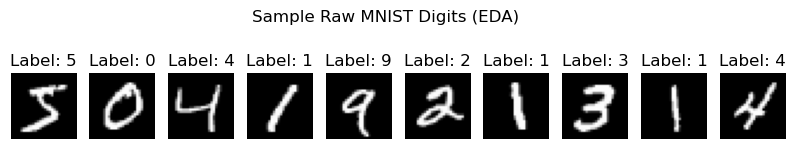

In [3]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train_raw[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Sample Raw MNIST Digits (EDA)", fontsize=12)
plt.show()


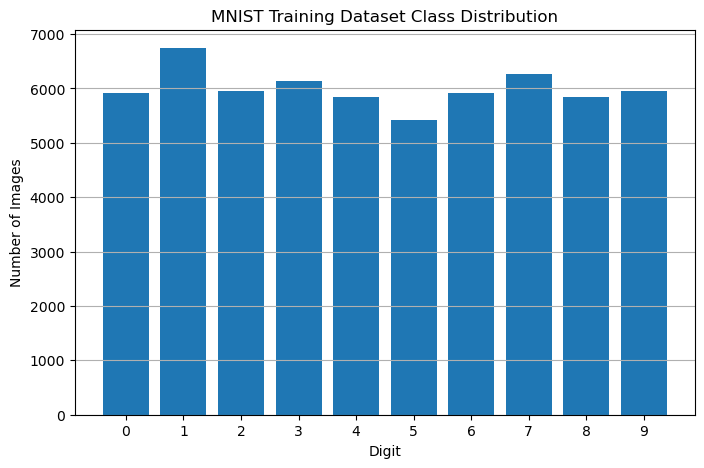

In [4]:
class_counts = np.bincount(y_train)

plt.figure(figsize=(8, 5))
plt.bar(range(10), class_counts)

plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("MNIST Training Dataset Class Distribution")
plt.xticks(range(10))
plt.grid(axis='y')

plt.show()

In [5]:
X_train = (X_train_raw.astype('float32') / 255.0).reshape(-1, 784)
X_test = (X_test_raw.astype('float32') / 255.0).reshape(-1, 784)

print(f"Training feature shape: {X_train.shape}")
print(f"Testing feature shape:  {X_test.shape}")

Training feature shape: (60000, 784)
Testing feature shape:  (10000, 784)


In [6]:
print("Preprocessing Verification")
print("-" * 40)
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Preprocessing Verification
----------------------------------------
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Training shape: (60000, 784)
Testing shape: (10000, 784)


In [7]:
model = Sequential([
    Input(shape=(784,)),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=128,
    validation_split=0.15,
    callbacks=[early_stop]
)

Epoch 1/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9024 - loss: 0.3316 - val_accuracy: 0.9589 - val_loss: 0.1394
Epoch 2/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9583 - loss: 0.1376 - val_accuracy: 0.9696 - val_loss: 0.0987
Epoch 3/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9697 - loss: 0.0975 - val_accuracy: 0.9776 - val_loss: 0.0790
Epoch 4/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9769 - loss: 0.0738 - val_accuracy: 0.9747 - val_loss: 0.0853
Epoch 5/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9805 - loss: 0.0630 - val_accuracy: 0.9773 - val_loss: 0.0738
Epoch 6/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9845 - loss: 0.0509 - val_accuracy: 0.9789 - val_loss: 0.0754
Epoch 7/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9855 - loss: 0.0440 - val_accuracy: 0.9791 - val_loss: 0.0747
Epoch 8/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9876 - loss: 0.0369 - val_accuracy: 0.

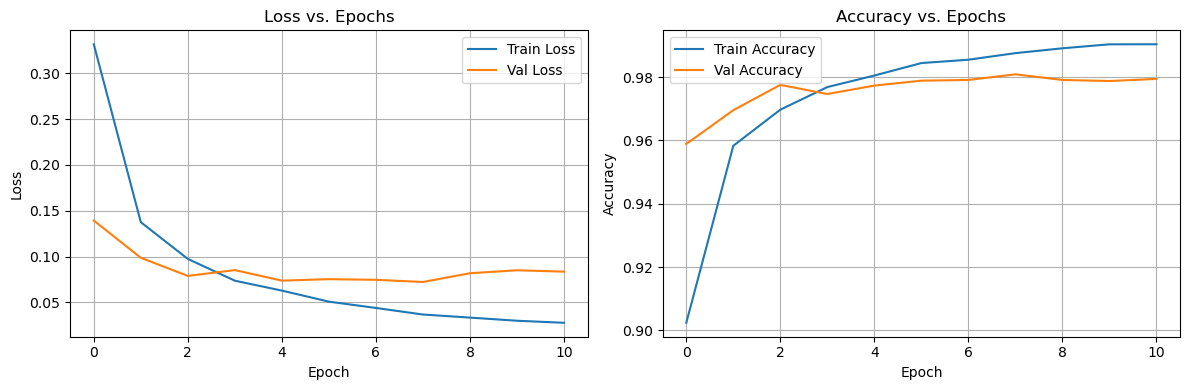

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss vs. Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy vs. Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [10]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Set Evaluation")
print("-" * 40)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Set Evaluation
----------------------------------------
Test Loss: 0.0715
Test Accuracy: 0.9789
Test Accuracy: 97.89%


In [11]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("=== Classification Report on MNIST Test Set ===")
print(classification_report(y_test, y_pred, digits=4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
=== Classification Report on MNIST Test Set ===
              precision    recall  f1-score   support

           0     0.9807    0.9878    0.9842       980
           1     0.9912    0.9894    0.9903      1135
           2     0.9731    0.9816    0.9773      1032
           3     0.9716    0.9832    0.9774      1010
           4     0.9815    0.9745    0.9780       982
           5     0.9841    0.9686    0.9763       892
           6     0.9793    0.9864    0.9828       958
           7     0.9900    0.9669    0.9783      1028
           8     0.9803    0.9702    0.9752       974
           9     0.9573    0.9782    0.9676      1009

    accuracy                         0.9789     10000
   macro avg     0.9789    0.9787    0.9788     10000
weighted avg     0.9790    0.9789    0.9789     10000



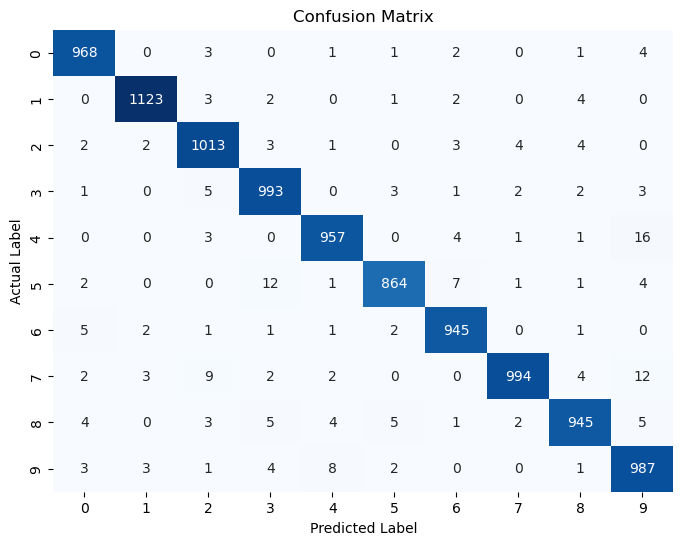

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

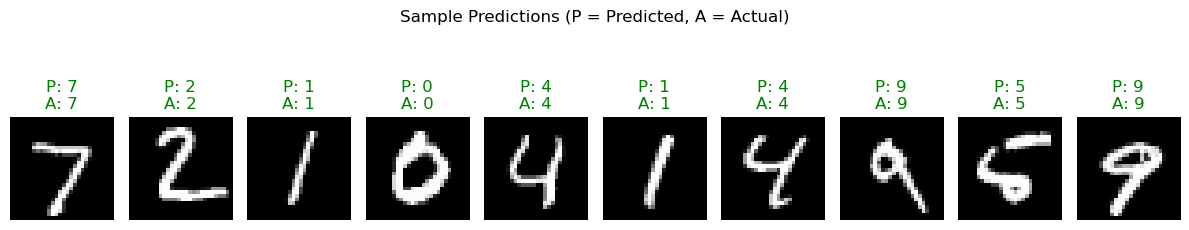

In [13]:
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_test_raw[i], cmap='gray')
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    plt.title(f"P: {y_pred[i]}\nA: {y_test[i]}", color=color)
    plt.axis('off')
plt.suptitle("Sample Predictions (P = Predicted, A = Actual)", fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print("=" * 50)

FINAL MODEL PERFORMANCE
Test Accuracy : 97.89%
Test Loss     : 0.0715


In [15]:
model.save("mnist_mlp_model.keras")

In [16]:
print("Model saved successfully!")

Model saved successfully!


In [17]:
import matplotlib.pyplot as plt

plt.imsave(
    "test_digit.png",
    X_test_raw[0],
    cmap="gray"
)

print("Actual digit:", y_test[0])

Actual digit: 7
